### Importing the Libraries and loading data

In [ ]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
 

train_df = pd.read_csv('../datasets/initial kaggle datasets/train.csv')
test_df = pd.read_csv('../datasets/initial kaggle datasets/test.csv')
sample_submission_df = pd.read_csv('../datasets/initial kaggle datasets/sample_submission.csv')

In [5]:
train_df

,id,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes
0,0,Mystery Matters,Episode 98,NaN,True Crime,74.81,Thursday,Night,NaN,0.0,Positive,31.41998
1,1,Joke Junction,Episode 26,119.80,Comedy,66.95,Saturday,Afternoon,75.95,2.0,Negative,88.01241
2,2,Study Sessions,Episode 16,73.90,Education,69.97,Tuesday,Evening,8.97,0.0,Negative,44.92531
3,3,Digital Digest,Episode 45,67.17,Technology,57.22,Monday,Morning,78.70,2.0,Positive,46.27824
4,4,Mind & Body,Episode 86,110.51,Health,80.07,Monday,Afternoon,58.68,3.0,Neutral,75.61031
...,...,...,...,...,...,...,...,...,...,...,...,...
749995,749995,Learning Lab,Episode 25,75.66,Education,69.36,Saturday,Morning,NaN,0.0,Negative,56.87058
749996,749996,Business Briefs,Episode 21,75.75,Business,35.21,Saturday,Night,NaN,2.0,Neutral,45.46242
749997,749997,Lifestyle Lounge,Episode 51,30.98,Lifestyle,78.58,Thursday,Morning,84.89,0.0,Negative,15.26000
749998,749998,Style Guide,Episode 47,108.98,Lifestyle,45.39,Thursday,Morning,93.27,0.0,Negative,100.72939


In [6]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750000 entries, 0 to 749999
Data columns (total 12 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           750000 non-null  int64  
 1   Podcast_Name                 750000 non-null  object 
 2   Episode_Title                750000 non-null  object 
 3   Episode_Length_minutes       662907 non-null  float64
 4   Genre                        750000 non-null  object 
 5   Host_Popularity_percentage   750000 non-null  float64
 6   Publication_Day              750000 non-null  object 
 7   Publication_Time             750000 non-null  object 
 8   Guest_Popularity_percentage  603970 non-null  float64
 9   Number_of_Ads                749999 non-null  float64
 10  Episode_Sentiment            750000 non-null  object 
 11  Listening_Time_minutes       750000 non-null  float64
dtypes: float64(5), int64(1), object(6)
memory usage: 68.7+ MB


In [7]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 11 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           250000 non-null  int64  
 1   Podcast_Name                 250000 non-null  object 
 2   Episode_Title                250000 non-null  object 
 3   Episode_Length_minutes       221264 non-null  float64
 4   Genre                        250000 non-null  object 
 5   Host_Popularity_percentage   250000 non-null  float64
 6   Publication_Day              250000 non-null  object 
 7   Publication_Time             250000 non-null  object 
 8   Guest_Popularity_percentage  201168 non-null  float64
 9   Number_of_Ads                250000 non-null  float64
 10  Episode_Sentiment            250000 non-null  object 
dtypes: float64(4), int64(1), object(6)
memory usage: 21.0+ MB


In [8]:
sample_submission_df

,id,Listening_Time_minutes
0,750000,45.437
1,750001,45.437
2,750002,45.437
3,750003,45.437
4,750004,45.437
...,...,...
249995,999995,45.437
249996,999996,45.437
249997,999997,45.437
249998,999998,45.437


# Explatory Data Analysis

### Distributions of Numeric Columns

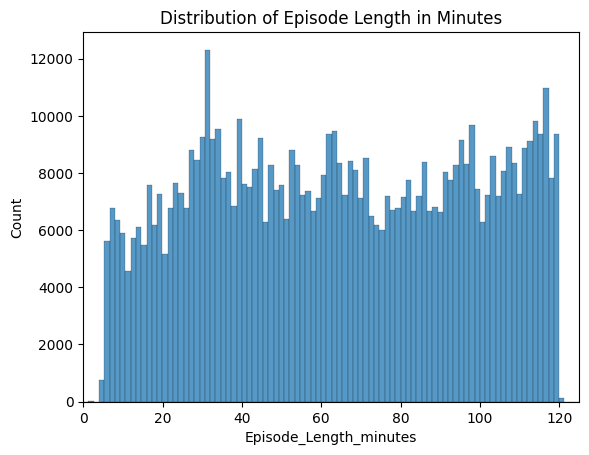

Average episode length in minutes: 64.50473835100327


In [9]:
sns.histplot(data=train_df, x='Episode_Length_minutes')
plt.xlim(0, 125)
plt.title('Distribution of Episode Length in Minutes')
plt.show()
print(f'Average episode length in minutes: {train_df["Episode_Length_minutes"].mean()}')

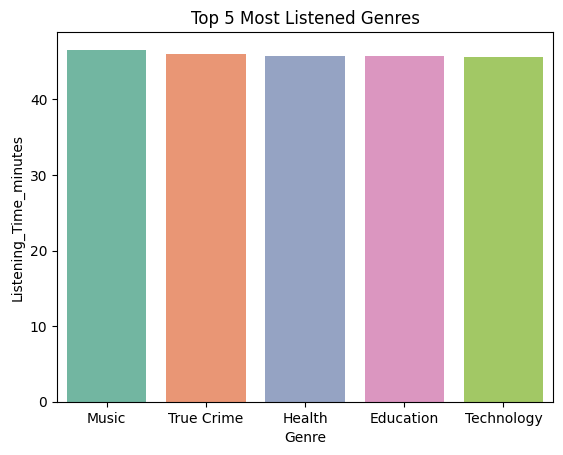

In [10]:
sns.barplot(data=pd.DataFrame(train_df.groupby('Genre')['Listening_Time_minutes'].mean().sort_values(ascending=False).head(5)),
             x='Genre', y='Listening_Time_minutes', hue='Genre', palette='Set2')
plt.title('Top 5 Most Listened Genres')
plt.show()

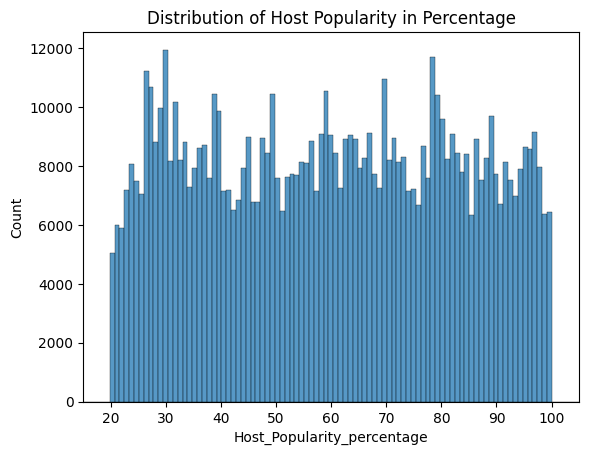

Average host popularity 59.859900753900014


In [11]:
sns.histplot(data=train_df, x='Host_Popularity_percentage')
plt.xlim(15,105)
plt.title('Distribution of Host Popularity in Percentage')
plt.show()
print(f"Average host popularity {train_df['Host_Popularity_percentage'].mean()}")

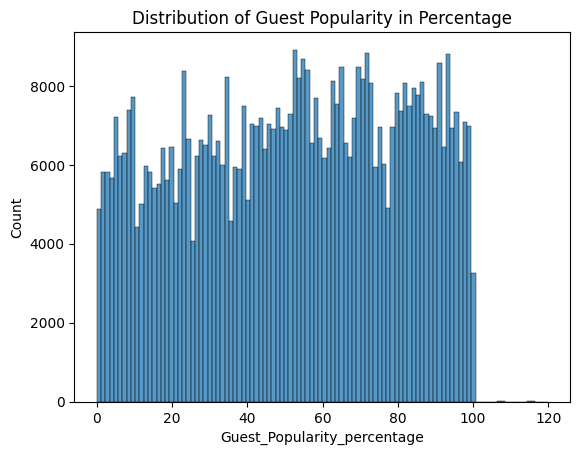

Average guest popularity 52.23644893379308


In [12]:
sns.histplot(data=train_df, x='Guest_Popularity_percentage')
plt.title('Distribution of Guest Popularity in Percentage')
plt.show()
print(f"Average guest popularity {train_df['Guest_Popularity_percentage'].mean()}")

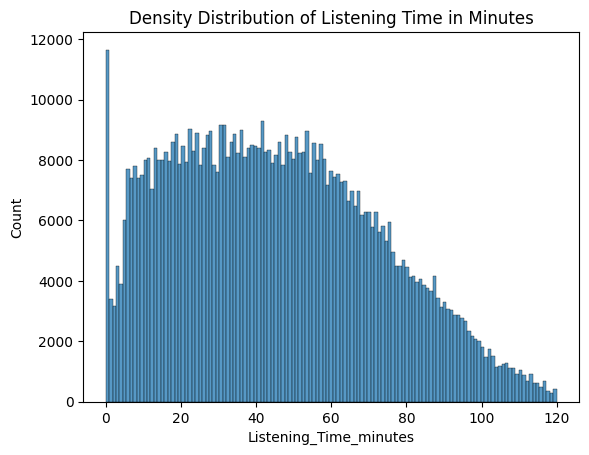

In [13]:
sns.histplot(data=train_df, x='Listening_Time_minutes')
plt.title('Density Distribution of Listening Time in Minutes')
plt.show()

### Checking the Unique Values in Categorical Columns

In [ ]:
train_df.Podcast_Name.nunique()

48

In [16]:
train_df.Episode_Title.nunique()

100

Episode Title Seems to only contain the number of the episode in sequence, maybe we can use this as a feature with removing the 'episode' text and only using the episode number.

In [17]:
train_df.Episode_Length_minutes.min(), train_df.Episode_Length_minutes.max()

(np.float64(0.0), np.float64(325.24))

In [18]:
test_df.Episode_Length_minutes.min(), test_df.Episode_Length_minutes.max()

(np.float64(2.47), np.float64(78486264.0))

An Episode cant have a total minute of 0, we will remove these later.

In [19]:
train_df.Genre.nunique()

10

In [ ]:
test_df.Genre.nunique()

10

In [21]:
train_df.Host_Popularity_percentage.min(), train_df.Host_Popularity_percentage.max()

(np.float64(1.3), np.float64(119.46))

In [22]:
test_df.Host_Popularity_percentage.min(), test_df.Host_Popularity_percentage.max()

(np.float64(2.49), np.float64(117.76))

Percentage cant go above 100%, we will modify these later as well.

In [23]:
train_df.Guest_Popularity_percentage.min(), train_df.Guest_Popularity_percentage.max()

(np.float64(0.0), np.float64(119.91))

In [24]:
test_df.Guest_Popularity_percentage.min(), test_df.Guest_Popularity_percentage.max()

(np.float64(0.0), np.float64(116.82))

In [25]:
train_df.Number_of_Ads.min(), train_df.Number_of_Ads.max()

(np.float64(0.0), np.float64(103.91))

In [26]:
test_df.Number_of_Ads.min(), test_df.Number_of_Ads.max()

(np.float64(0.0), np.float64(2063.0))

In [27]:
train_df[
    train_df['Number_of_Ads'] >= 4
]

,id,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes
211159,211159,Wellness Wave,Episode 83,64.83,Health,48.46,Sunday,Evening,NaN,53.37,Positive,50.44892
283606,283606,Health Hour,Episode 15,109.93,Health,67.81,Sunday,Morning,77.90,103.91,Neutral,103.89696
436577,436577,Sports Central,Episode 64,115.25,Sports,28.58,Saturday,Afternoon,23.65,103.00,Neutral,103.12686
495919,495919,Comedy Corner,Episode 79,64.83,Comedy,48.37,Saturday,Evening,NaN,53.42,Neutral,50.44892
537705,537705,Sound Waves,Episode 64,112.27,Music,28.95,Saturday,Morning,10.15,103.75,Neutral,103.12686
567235,567235,Detective Diaries,Episode 21,16.13,True Crime,49.11,Tuesday,Evening,43.17,12.00,Positive,6.49000
602553,602553,Sound Waves,Episode 53,112.27,Music,28.19,Tuesday,Morning,23.15,103.25,Neutral,103.12686
672139,672139,Sound Waves,Episode 35,115.74,Music,28.95,Tuesday,Afternoon,23.50,103.25,Neutral,103.12686
683147,683147,Crime Chronicles,Episode 15,109.93,True Crime,59.66,Tuesday,Evening,77.91,103.88,Neutral,103.89696


In [28]:
test_df[
    test_df['Number_of_Ads'] >= 4
]

,id,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment
37939,787939,Life Lessons,Episode 94,89.84,Lifestyle,60.79,Sunday,Afternoon,62.13,89.12,Neutral
178393,928393,Tech Trends,Episode 59,7.15,Technology,71.90,Sunday,Morning,17.39,2063.00,Positive


Only a couple of rows, we will also get rid of these extreme values.

In [29]:
train_df.Listening_Time_minutes.min(), train_df.Listening_Time_minutes.max()

(np.float64(0.0), np.float64(119.97))

In [30]:
train_df[train_df['Listening_Time_minutes'] > 100]

,id,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes
11,11,Melody Mix,Episode 62,107.26,Music,78.12,Monday,Evening,78.12,1.0,Positive,103.56000
27,27,Innovators,Episode 31,113.68,Technology,38.49,Wednesday,Afternoon,28.53,0.0,Positive,112.68000
32,32,Sound Waves,Episode 74,117.88,Music,41.28,Saturday,Morning,NaN,0.0,Positive,101.19214
179,179,Joke Junction,Episode 47,113.26,Comedy,68.83,Monday,Evening,63.39,1.0,Neutral,106.76049
185,185,News Roundup,Episode 61,118.67,News,70.45,Friday,Evening,20.20,0.0,Neutral,117.15000
...,...,...,...,...,...,...,...,...,...,...,...,...
749815,749815,World Watch,Episode 86,118.92,News,92.14,Monday,Night,NaN,1.0,Neutral,118.97425
749836,749836,Athlete's Arena,Episode 99,118.17,Sports,90.51,Tuesday,Night,91.40,2.0,Neutral,117.15000
749934,749934,Global News,Episode 8,115.41,News,98.41,Sunday,Evening,5.80,2.0,Negative,106.55935
749944,749944,Healthy Living,Episode 95,106.48,Health,81.24,Tuesday,Evening,17.08,0.0,Negative,101.58450


### Correlation Matrix

In [31]:
train_df.select_dtypes(include=np.number).corr()

,id,Episode_Length_minutes,Host_Popularity_percentage,Guest_Popularity_percentage,Number_of_Ads,Listening_Time_minutes
id,1.000000,-0.000557,0.000274,0.000637,0.000771,-0.000876
Episode_Length_minutes,-0.000557,1.000000,0.023596,-0.009704,-0.054953,0.916749
Host_Popularity_percentage,0.000274,0.023596,1.000000,0.022431,-0.017896,0.050870
Guest_Popularity_percentage,0.000637,-0.009704,0.022431,1.000000,0.007933,-0.016014
Number_of_Ads,0.000771,-0.054953,-0.017896,0.007933,1.000000,-0.118337
Listening_Time_minutes,-0.000876,0.916749,0.050870,-0.016014,-0.118337,1.000000


<Axes: >

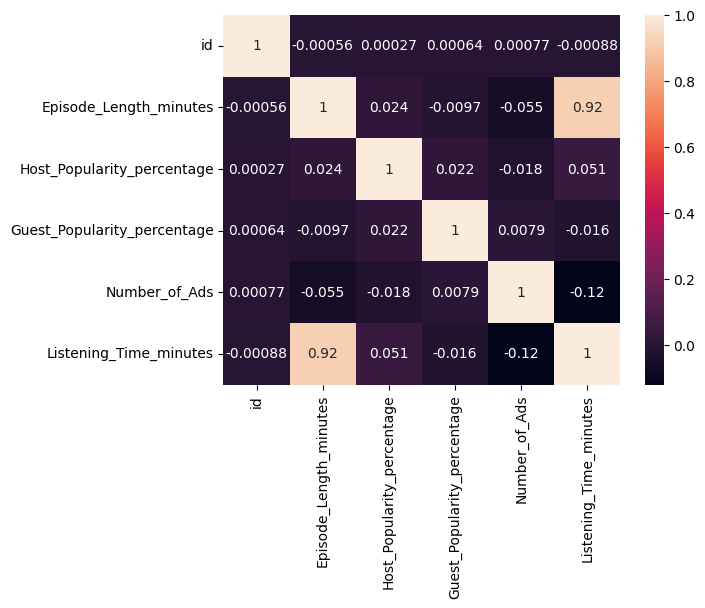

In [ ]:
sns.heatmap(data=train_df.select_dtypes(include=np.number).corr(), annot=True);

The only good correlation exists between the episode length and listening time in minutes. 

## EDA Findings
### Distribution
* We are working with a evenly distributed dataset here. We have peak values here and there, but mostly the dataset is uniform. We can use the peak values as a way to integrate feature engineering down the line.
### Missing and Incorrect Values
* We have missing values in 2-3 of our columns. We will impute and/or delete these data points. Plus, in some of our columns we have values like 110 percent out of 100, which is mathamatically incorrect.






# Data Cleaning 

In [33]:
train_df

,id,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes
0,0,Mystery Matters,Episode 98,NaN,True Crime,74.81,Thursday,Night,NaN,0.0,Positive,31.41998
1,1,Joke Junction,Episode 26,119.80,Comedy,66.95,Saturday,Afternoon,75.95,2.0,Negative,88.01241
2,2,Study Sessions,Episode 16,73.90,Education,69.97,Tuesday,Evening,8.97,0.0,Negative,44.92531
3,3,Digital Digest,Episode 45,67.17,Technology,57.22,Monday,Morning,78.70,2.0,Positive,46.27824
4,4,Mind & Body,Episode 86,110.51,Health,80.07,Monday,Afternoon,58.68,3.0,Neutral,75.61031
...,...,...,...,...,...,...,...,...,...,...,...,...
749995,749995,Learning Lab,Episode 25,75.66,Education,69.36,Saturday,Morning,NaN,0.0,Negative,56.87058
749996,749996,Business Briefs,Episode 21,75.75,Business,35.21,Saturday,Night,NaN,2.0,Neutral,45.46242
749997,749997,Lifestyle Lounge,Episode 51,30.98,Lifestyle,78.58,Thursday,Morning,84.89,0.0,Negative,15.26000
749998,749998,Style Guide,Episode 47,108.98,Lifestyle,45.39,Thursday,Morning,93.27,0.0,Negative,100.72939


In [34]:
test_df

,id,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment
0,750000,Educational Nuggets,Episode 73,78.96,Education,38.11,Saturday,Evening,53.33,1.0,Neutral
1,750001,Sound Waves,Episode 23,27.87,Music,71.29,Sunday,Morning,NaN,0.0,Neutral
2,750002,Joke Junction,Episode 11,69.10,Comedy,67.89,Friday,Evening,97.51,0.0,Positive
3,750003,Comedy Corner,Episode 73,115.39,Comedy,23.40,Sunday,Morning,51.75,2.0,Positive
4,750004,Life Lessons,Episode 50,72.32,Lifestyle,58.10,Wednesday,Morning,11.30,2.0,Neutral
...,...,...,...,...,...,...,...,...,...,...,...
249995,999995,Mind & Body,Episode 100,21.05,Health,65.77,Saturday,Evening,96.40,3.0,Negative
249996,999996,Joke Junction,Episode 85,85.50,Comedy,41.47,Saturday,Night,30.52,2.0,Negative
249997,999997,Joke Junction,Episode 63,12.11,Comedy,25.92,Thursday,Evening,73.69,1.0,Neutral
249998,999998,Market Masters,Episode 46,113.46,Business,43.47,Friday,Night,93.59,3.0,Positive


* We will remove the text 'Episode' from the Episode Title, and use the data as an int64 format. We will call the columns Episode Number instead.

In [35]:
train_df['Episode_Title'] = train_df['Episode_Title'].str.replace('Episode', '')
test_df['Episode_Title'] = test_df['Episode_Title'].str.replace('Episode', '')

In [36]:
train_df.rename(columns={'Episode_Title': 'episode_number'}, inplace=True)
test_df.rename(columns={'Episode_Title': 'episode_number'}, inplace=True)

In [37]:
train_df['episode_number'] = train_df['episode_number'].astype('int64')
test_df['episode_number'] = test_df['episode_number'].astype('int64')

In [38]:
train_df.isna().sum()

id                                  0
Podcast_Name                        0
episode_number                      0
Episode_Length_minutes          87093
Genre                               0
Host_Popularity_percentage          0
Publication_Day                     0
Publication_Time                    0
Guest_Popularity_percentage    146030
Number_of_Ads                       1
Episode_Sentiment                   0
Listening_Time_minutes              0
dtype: int64

In [39]:
test_df.isna().sum()

id                                 0
Podcast_Name                       0
episode_number                     0
Episode_Length_minutes         28736
Genre                              0
Host_Popularity_percentage         0
Publication_Day                    0
Publication_Time                   0
Guest_Popularity_percentage    48832
Number_of_Ads                      0
Episode_Sentiment                  0
dtype: int64

we only have 1 missing number of ads data in our training dataset, we can manually fill this. and for the other two columns that hold missing data, 'episode length minutes' and 'guest popularity percentage', we will use an imputer. 

In [40]:
x = train_df[train_df['Number_of_Ads'].isna() == True].index
train_df.loc[x, 'Number_of_Ads'] = 0

In [41]:
train_df.isna().sum()

id                                  0
Podcast_Name                        0
episode_number                      0
Episode_Length_minutes          87093
Genre                               0
Host_Popularity_percentage          0
Publication_Day                     0
Publication_Time                    0
Guest_Popularity_percentage    146030
Number_of_Ads                       0
Episode_Sentiment                   0
Listening_Time_minutes              0
dtype: int64

### I would assume the null values in Guest_popularity_percentage actually stems from not having any guests in that particular episode. So, we will set those values to 0.

In [ ]:
train_df['Guest_Popularity_percentage'] = train_df['Guest_Popularity_percentage'].fillna(0)
test_df['Guest_Popularity_percentage'] = test_df['Guest_Popularity_percentage'].fillna(0)

In [43]:
train_df.isna().sum()

id                                 0
Podcast_Name                       0
episode_number                     0
Episode_Length_minutes         87093
Genre                              0
Host_Popularity_percentage         0
Publication_Day                    0
Publication_Time                   0
Guest_Popularity_percentage        0
Number_of_Ads                      0
Episode_Sentiment                  0
Listening_Time_minutes             0
dtype: int64

In [44]:
test_df.isna().sum()

id                                 0
Podcast_Name                       0
episode_number                     0
Episode_Length_minutes         28736
Genre                              0
Host_Popularity_percentage         0
Publication_Day                    0
Publication_Time                   0
Guest_Popularity_percentage        0
Number_of_Ads                      0
Episode_Sentiment                  0
dtype: int64

### For episode length in minutes, we will simply use a scikit learn imputer and set the values to the mean of the training dataset. We will make sure to train the imputer according to the training data in order to avoid data leakage.

In [ ]:
col_to_impute = ['Episode_Length_minutes']

imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
imputer.fit(train_df[col_to_impute])

train_df[col_to_impute] = imputer.transform(train_df[col_to_impute])
test_df[col_to_impute] = imputer.transform(test_df[col_to_impute])

In [48]:
train_df

,id,Podcast_Name,episode_number,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes
0,0,Mystery Matters,98,64.504738,True Crime,74.81,Thursday,Night,0.00,0.0,Positive,31.41998
1,1,Joke Junction,26,119.800000,Comedy,66.95,Saturday,Afternoon,75.95,2.0,Negative,88.01241
2,2,Study Sessions,16,73.900000,Education,69.97,Tuesday,Evening,8.97,0.0,Negative,44.92531
3,3,Digital Digest,45,67.170000,Technology,57.22,Monday,Morning,78.70,2.0,Positive,46.27824
4,4,Mind & Body,86,110.510000,Health,80.07,Monday,Afternoon,58.68,3.0,Neutral,75.61031
...,...,...,...,...,...,...,...,...,...,...,...,...
749995,749995,Learning Lab,25,75.660000,Education,69.36,Saturday,Morning,0.00,0.0,Negative,56.87058
749996,749996,Business Briefs,21,75.750000,Business,35.21,Saturday,Night,0.00,2.0,Neutral,45.46242
749997,749997,Lifestyle Lounge,51,30.980000,Lifestyle,78.58,Thursday,Morning,84.89,0.0,Negative,15.26000
749998,749998,Style Guide,47,108.980000,Lifestyle,45.39,Thursday,Morning,93.27,0.0,Negative,100.72939


In [49]:
test_df

,id,Podcast_Name,episode_number,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment
0,750000,Educational Nuggets,73,78.96,Education,38.11,Saturday,Evening,53.33,1.0,Neutral
1,750001,Sound Waves,23,27.87,Music,71.29,Sunday,Morning,0.00,0.0,Neutral
2,750002,Joke Junction,11,69.10,Comedy,67.89,Friday,Evening,97.51,0.0,Positive
3,750003,Comedy Corner,73,115.39,Comedy,23.40,Sunday,Morning,51.75,2.0,Positive
4,750004,Life Lessons,50,72.32,Lifestyle,58.10,Wednesday,Morning,11.30,2.0,Neutral
...,...,...,...,...,...,...,...,...,...,...,...
249995,999995,Mind & Body,100,21.05,Health,65.77,Saturday,Evening,96.40,3.0,Negative
249996,999996,Joke Junction,85,85.50,Comedy,41.47,Saturday,Night,30.52,2.0,Negative
249997,999997,Joke Junction,63,12.11,Comedy,25.92,Thursday,Evening,73.69,1.0,Neutral
249998,999998,Market Masters,46,113.46,Business,43.47,Friday,Night,93.59,3.0,Positive


### The missing values in Episode Length minutes has been filled with the training datasets mean value for the appropriate colummn.

In [50]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750000 entries, 0 to 749999
Data columns (total 12 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           750000 non-null  int64  
 1   Podcast_Name                 750000 non-null  object 
 2   episode_number               750000 non-null  int64  
 3   Episode_Length_minutes       750000 non-null  float64
 4   Genre                        750000 non-null  object 
 5   Host_Popularity_percentage   750000 non-null  float64
 6   Publication_Day              750000 non-null  object 
 7   Publication_Time             750000 non-null  object 
 8   Guest_Popularity_percentage  750000 non-null  float64
 9   Number_of_Ads                750000 non-null  float64
 10  Episode_Sentiment            750000 non-null  object 
 11  Listening_Time_minutes       750000 non-null  float64
dtypes: float64(5), int64(2), object(5)
memory usage: 68.7+ MB


### Our Host/Guest popularity percentage columns hold data points that go above 100 percent, we will set these values equal to 100 instead. 

In [51]:
train_df.Host_Popularity_percentage.max(), test_df.Host_Popularity_percentage.max() 

(np.float64(119.46), np.float64(117.76))

In [52]:
train_df.Guest_Popularity_percentage.max(), test_df.Guest_Popularity_percentage.max() 

(np.float64(119.91), np.float64(116.82))

In [53]:
train_df['Host_Popularity_percentage'] = train_df['Host_Popularity_percentage'].apply(lambda x: 100 if x > 100 else x)
test_df['Host_Popularity_percentage'] = test_df['Host_Popularity_percentage'].apply(lambda x: 100 if x > 100 else x)

train_df['Guest_Popularity_percentage'] = train_df['Guest_Popularity_percentage'].apply(lambda x: 100 if x > 100 else x)
test_df['Guest_Popularity_percentage'] = test_df['Guest_Popularity_percentage'].apply(lambda x: 100 if x > 100 else x)

In [54]:
train_df.Host_Popularity_percentage.max(), test_df.Host_Popularity_percentage.max() 

(np.float64(100.0), np.float64(100.0))

In [55]:
train_df.Guest_Popularity_percentage.max(), test_df.Guest_Popularity_percentage.max() 

(np.float64(100.0), np.float64(100.0))

### Lets check for our last numeric column, number of ads

In [56]:
train_df.Number_of_Ads.min(),  train_df.Number_of_Ads.max()

(np.float64(0.0), np.float64(103.91))

In [57]:
test_df.Number_of_Ads.min(),  test_df.Number_of_Ads.max()

(np.float64(0.0), np.float64(2063.0))

the max values are impossible and most likely are errors. we will fix these values to the most possible maximum value for ads, which is 3.

In [58]:
x = train_df[train_df['Number_of_Ads'] > 3].index
y = test_df[test_df['Number_of_Ads'] > 3].index

train_df.loc[x, 'Number_of_Ads'] = 3
test_df.loc[y, 'Number_of_Ads'] = 3

In [59]:
train_df.Number_of_Ads.min(),  train_df.Number_of_Ads.max()

(np.float64(0.0), np.float64(3.0))

In [60]:
test_df.Number_of_Ads.min(),  test_df.Number_of_Ads.max()

(np.float64(0.0), np.float64(3.0))

In [61]:
train_df

,id,Podcast_Name,episode_number,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes
0,0,Mystery Matters,98,64.504738,True Crime,74.81,Thursday,Night,0.00,0.0,Positive,31.41998
1,1,Joke Junction,26,119.800000,Comedy,66.95,Saturday,Afternoon,75.95,2.0,Negative,88.01241
2,2,Study Sessions,16,73.900000,Education,69.97,Tuesday,Evening,8.97,0.0,Negative,44.92531
3,3,Digital Digest,45,67.170000,Technology,57.22,Monday,Morning,78.70,2.0,Positive,46.27824
4,4,Mind & Body,86,110.510000,Health,80.07,Monday,Afternoon,58.68,3.0,Neutral,75.61031
...,...,...,...,...,...,...,...,...,...,...,...,...
749995,749995,Learning Lab,25,75.660000,Education,69.36,Saturday,Morning,0.00,0.0,Negative,56.87058
749996,749996,Business Briefs,21,75.750000,Business,35.21,Saturday,Night,0.00,2.0,Neutral,45.46242
749997,749997,Lifestyle Lounge,51,30.980000,Lifestyle,78.58,Thursday,Morning,84.89,0.0,Negative,15.26000
749998,749998,Style Guide,47,108.980000,Lifestyle,45.39,Thursday,Morning,93.27,0.0,Negative,100.72939


In [62]:
test_df

,id,Podcast_Name,episode_number,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment
0,750000,Educational Nuggets,73,78.96,Education,38.11,Saturday,Evening,53.33,1.0,Neutral
1,750001,Sound Waves,23,27.87,Music,71.29,Sunday,Morning,0.00,0.0,Neutral
2,750002,Joke Junction,11,69.10,Comedy,67.89,Friday,Evening,97.51,0.0,Positive
3,750003,Comedy Corner,73,115.39,Comedy,23.40,Sunday,Morning,51.75,2.0,Positive
4,750004,Life Lessons,50,72.32,Lifestyle,58.10,Wednesday,Morning,11.30,2.0,Neutral
...,...,...,...,...,...,...,...,...,...,...,...
249995,999995,Mind & Body,100,21.05,Health,65.77,Saturday,Evening,96.40,3.0,Negative
249996,999996,Joke Junction,85,85.50,Comedy,41.47,Saturday,Night,30.52,2.0,Negative
249997,999997,Joke Junction,63,12.11,Comedy,25.92,Thursday,Evening,73.69,1.0,Neutral
249998,999998,Market Masters,46,113.46,Business,43.47,Friday,Night,93.59,3.0,Positive


## Cleaning Steps
* And just like that, we have removed outliers and unmathematical data points that existed in our dataset.

In [ ]:
### dumping the cleaned datasets to a csv format.
train_df.to_csv('../Datasets/cleaned datasets/train.csv', index=None)
test_df.to_csv('../Datasets/cleaned datasets/test.csv', index=None)